In [1]:
import random
import numpy as np
import torch
from pathlib import Path
from safetensors.torch import load_file

SEED = 42
TRAIN_DIR = Path("../outputs/triviaqa-train__Qwen3-8B-non-thinking/probing_dataset")
NUM_SAMPLES_LIST = [3736, 7473, 14946, 29892, 59784, 76523]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load full training hidden states and mean-pool across layers
hs_data = load_file(TRAIN_DIR / "hidden_states.safetensors")
hidden_states = hs_data["hidden_states"].mean(dim=1).float()  # (n_examples, hidden_dim)
total_samples = hidden_states.shape[0]
print(f"Total training samples: {total_samples}, hidden_dim: {hidden_states.shape[1]}")

# Reproduce the exact subsample indices from train_probe.py (seed=42, torch.randperm)
torch.manual_seed(SEED)
perm = torch.randperm(total_samples)

for num_samples in NUM_SAMPLES_LIST:
    indices = perm[:num_samples]
    subset = hidden_states[indices]
    mean = subset.mean(dim=0)
    std = subset.std(dim=0) + 1e-8
    print(f"\nNUM_SAMPLES={num_samples}")
    print(f"  mean: min={mean.min().item():.6f}, max={mean.max().item():.6f}, avg={mean.mean().item():.6f}")
    print(f"  std:  min={std.min().item():.6f}, max={std.max().item():.6f}, avg={std.mean().item():.6f}")

Total training samples: 76523, hidden_dim: 4096

NUM_SAMPLES=3736
  mean: min=-11.239561, max=54.578827, avg=-0.050507
  std:  min=0.255647, max=3.312441, avg=0.394728

NUM_SAMPLES=7473
  mean: min=-11.243426, max=54.551888, avg=-0.050486
  std:  min=0.252274, max=3.330217, avg=0.393115

NUM_SAMPLES=14946
  mean: min=-11.239236, max=54.544930, avg=-0.050380
  std:  min=0.252080, max=3.342441, avg=0.394068

NUM_SAMPLES=29892
  mean: min=-11.239537, max=54.563396, avg=-0.050356
  std:  min=0.251704, max=3.352373, avg=0.394426

NUM_SAMPLES=59784
  mean: min=-11.236448, max=54.544254, avg=-0.050353
  std:  min=0.250381, max=3.342817, avg=0.393912

NUM_SAMPLES=76523
  mean: min=-11.238791, max=54.551849, avg=-0.050329
  std:  min=0.250802, max=3.343243, avg=0.393751


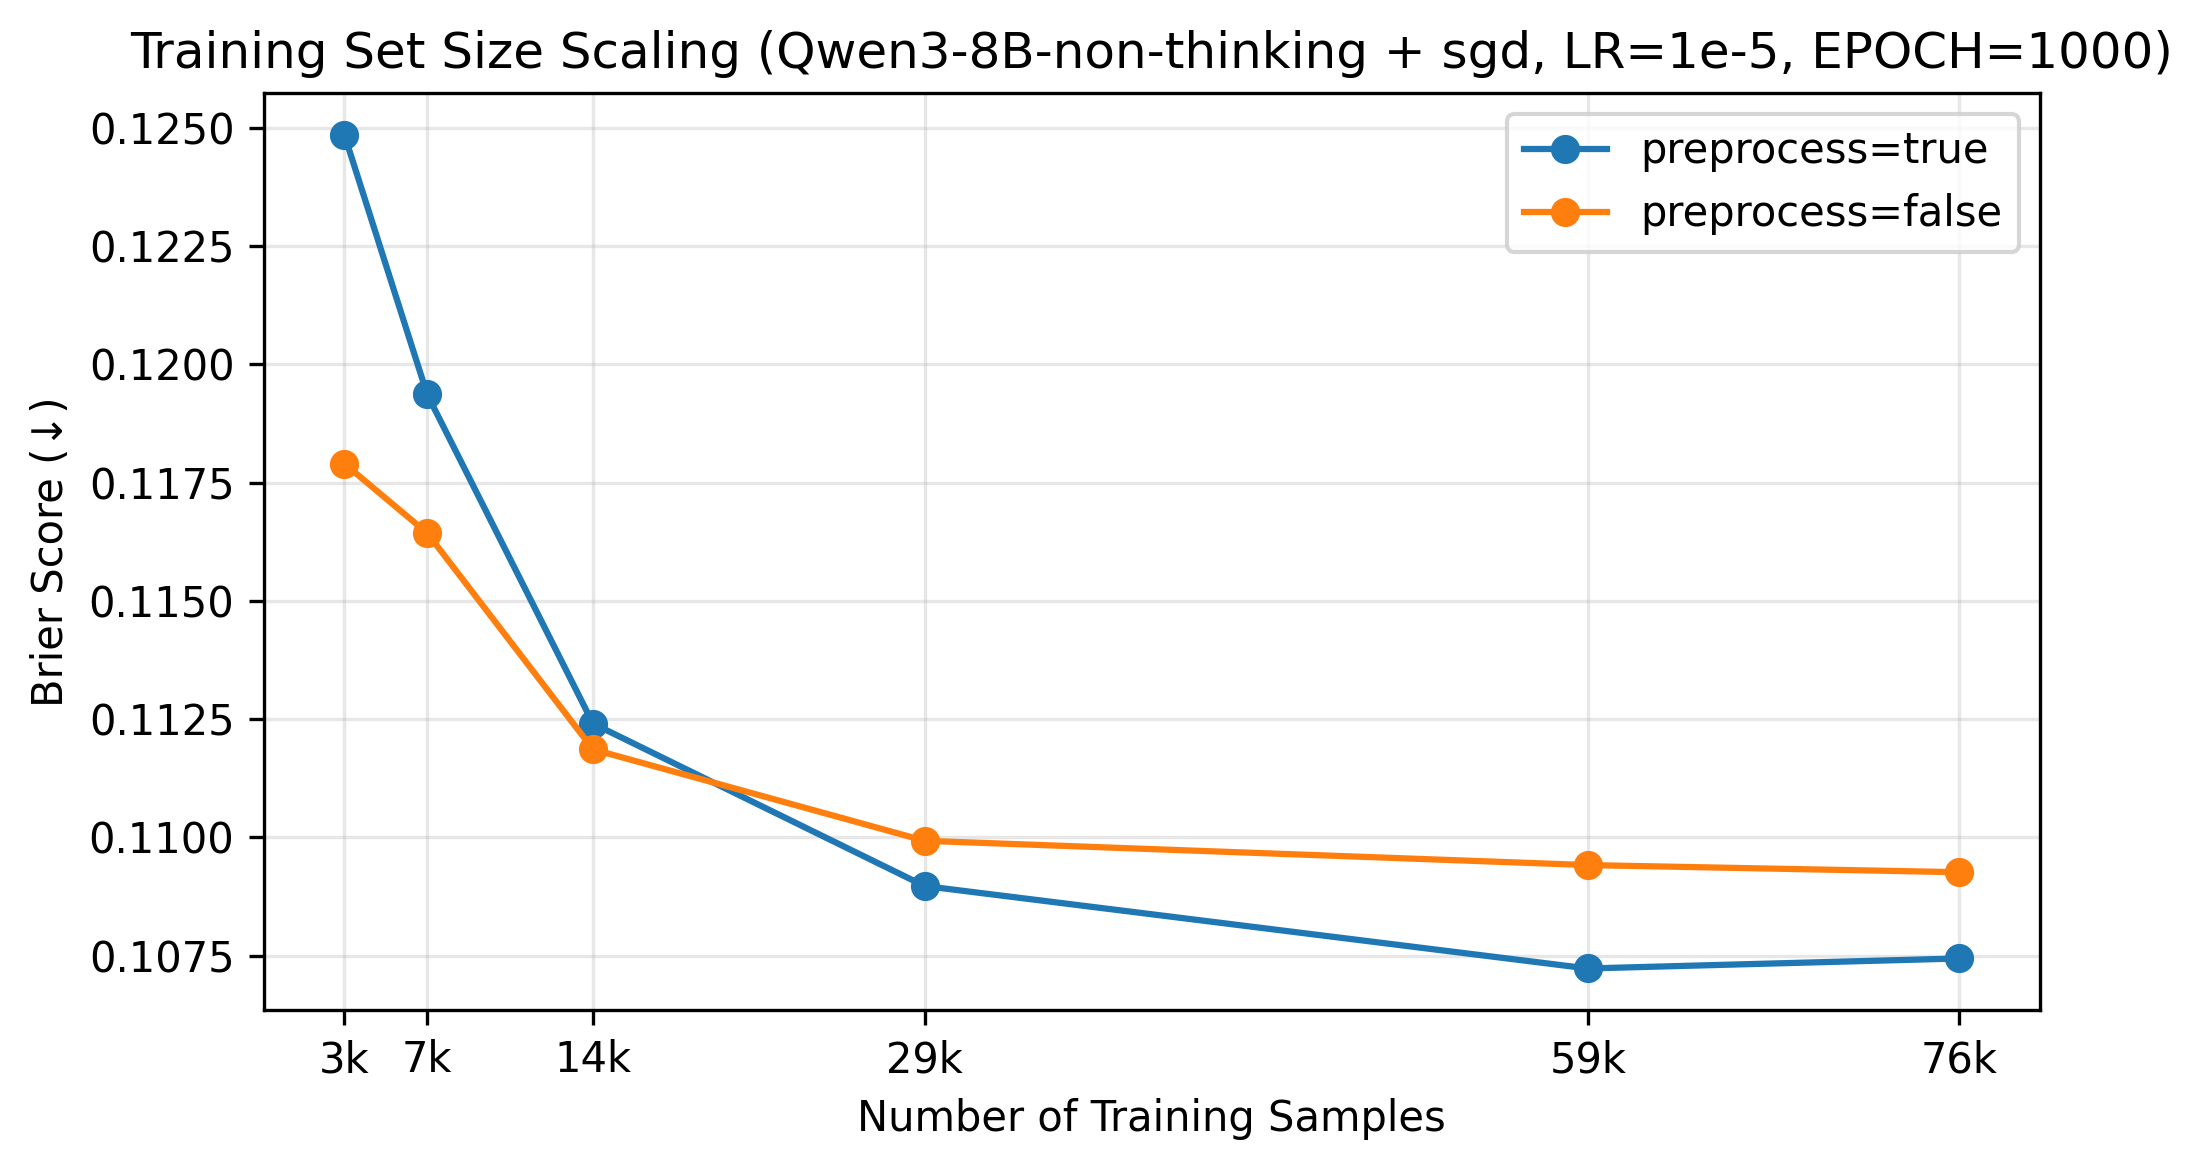

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

OPTIMIZER = "sgd"
LR = "1e-5"  # or "1e-4"
EPOCH = "1000"  # or "100"
MODEL_NAME = "Qwen3-8B-non-thinking"
BASE_DIR = Path(f"../outputs/triviaqa-train__{MODEL_NAME}/probes")

NUM_SAMPLES = [3736, 7473, 14946, 29892, 59784, 76523]
PREPROCESSES = ["true", "false"]

PROBE_TEMPLATE = (
    f"linear__loss-bce__optimizer-{OPTIMIZER}__lr-{LR}__lr_scheduler-none"
    f"__weight_decay-1e-2__batch_size-32__epochs-{EPOCH}"
    "__preprocess-{preprocess}__apply_sigmoid-false__num_samples-{num_samples}"
)

mse = {pp: [] for pp in PREPROCESSES}

for pp in PREPROCESSES:
    for ns in NUM_SAMPLES:
        results_path = BASE_DIR / PROBE_TEMPLATE.format(preprocess=pp, num_samples=ns) / "layer_mean_pooled" / "results.json"
        with open(results_path) as f:
            data = json.load(f)
        mse[pp].append(data["evaluation"]["mse"])

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)
for pp in PREPROCESSES:
    label = f"preprocess={pp}"
    ax.plot(NUM_SAMPLES, mse[pp], marker="o", label=label)

ax.set_xlabel("Number of Training Samples")
ax.set_ylabel("Brier Score (↓)")
ax.set_title(f"Training Set Size Scaling ({MODEL_NAME} + {OPTIMIZER}, LR={LR}, EPOCH={EPOCH})")
ax.set_xticks(NUM_SAMPLES)
ax.set_xticklabels([f"{n//1000}k" for n in NUM_SAMPLES])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()